In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [ ]:
df=pd.read_csv("post natal data.csv")
df.head()

,Timestamp,Age,Feeling sad or Tearful,Irritable towards baby & partner,Trouble sleeping at night,Problems concentrating or making decision,Overeating or loss of appetite,Feeling anxious,Feeling of guilt,Problems of bonding with baby,Suicide attempt
0,6/14/2022 20:02,35-40,Yes,Yes,Two or more days a week,Yes,Yes,Yes,No,Yes,Yes
1,6/14/2022 20:03,40-45,Yes,No,No,Yes,Yes,No,Yes,Yes,No
2,6/14/2022 20:04,35-40,Yes,No,Yes,Yes,Yes,Yes,No,Sometimes,No
3,6/14/2022 20:05,35-40,Yes,Yes,Yes,Yes,No,Yes,Maybe,No,No
4,6/14/2022 20:06,40-45,Yes,No,Two or more days a week,Yes,No,Yes,No,Yes,No


In [ ]:
df.drop("Timestamp", axis=1, inplace=True)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1503 entries, 0 to 1502
Data columns (total 10 columns):
 #   Column                                     Non-Null Count  Dtype 
---  ------                                     --------------  ----- 
 0   Age                                        1503 non-null   object
 1   Feeling sad or Tearful                     1503 non-null   object
 2   Irritable towards baby & partner           1497 non-null   object
 3   Trouble sleeping at night                  1503 non-null   object
 4   Problems concentrating or making decision  1491 non-null   object
 5   Overeating or loss of appetite             1503 non-null   object
 6   Feeling anxious                            1503 non-null   object
 7   Feeling of guilt                           1494 non-null   object
 8   Problems of bonding with baby              1503 non-null   object
 9   Suicide attempt                            1503 non-null   object
dtypes: object(10)
memory usage: 117.6+ K

In [ ]:
df.isnull().sum()

Age                                           0
Feeling sad or Tearful                        0
Irritable towards baby & partner              6
Trouble sleeping at night                     0
Problems concentrating or making decision    12
Overeating or loss of appetite                0
Feeling anxious                               0
Feeling of guilt                              9
Problems of bonding with baby                 0
Suicide attempt                               0
dtype: int64

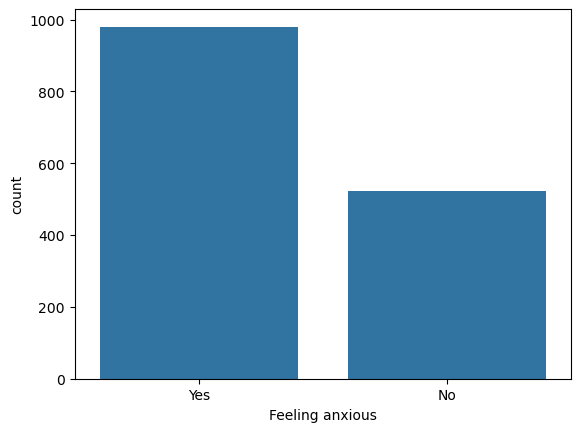

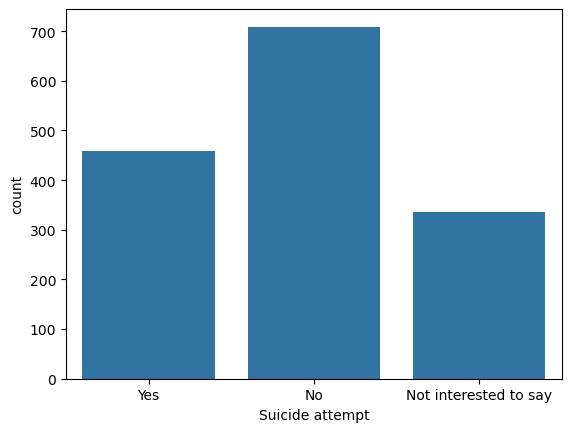

In [ ]:
sns.countplot(x="Feeling anxious", data=df)
plt.show()

sns.countplot(x="Suicide attempt", data=df)
plt.show()

In [ ]:
age_map = {
"18-25":1,
"25-30":2,
"30-35":3,
"35-40":4,
"40-45":5
}

df["Age"] = df["Age"].map(age_map)

In [ ]:
df["Feeling anxious"] = df["Feeling anxious"].map({"Yes":1,"No":0})

df["Suicide attempt"] = df["Suicide attempt"].map({"Yes":1,"No":0})

In [ ]:
from sklearn.preprocessing import OrdinalEncoder

symptom_cols = [
"Feeling sad or Tearful",
"Irritable towards baby & partner",
"Trouble sleeping at night",
"Problems concentrating or making decision",
"Overeating or loss of appetite",
"Feeling of guilt",
"Problems of bonding with baby"
]

encoder = OrdinalEncoder()

df[symptom_cols] = encoder.fit_transform(df[symptom_cols])

In [ ]:
df["symptom_score"] = df[symptom_cols].sum(axis=1)

In [ ]:
from imblearn.over_sampling import SMOTE

smote = SMOTE()

X_res, y_res = smote.fit_resample(X, y)

ModuleNotFoundError: No module named 'imblearn'

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
X_res,
y_res,
test_size=0.2,
random_state=42
)

In [ ]:
y_pred = model.predict(X_test)

In [ ]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

In [ ]:
from sklearn.metrics import roc_auc_score

prob = model.predict_proba(X_test)

anxiety_prob = prob[0][:,1]
suicide_prob = prob[1][:,1]

print("Anxiety ROC-AUC:", roc_auc_score(y_test["Feeling anxious"], anxiety_prob))
print("Suicide ROC-AUC:", roc_auc_score(y_test["Suicide attempt"], suicide_prob))